## Análisis y detección de anomalías de red a partir del conjunto de datos NSL-KDD-Dataset

# 2. Contextualización y problema
****

## 2.1. Contexto de la base de datos
El **KDD Cup 1999 Dataset** es un conjunto de datos utilizado en el campo de la **detección de intrusiones** y la **seguridad informática**, creado como parte de una competencia organizada por el **DARPA (Defense Advanced Research Projects Agency)**. Este dataset fue generado a partir de simulaciones de tráfico de red, el cual durante nueve semanas se dedicó a capturar tanto conexiones normales como actividades maliciosas (intrusiones). Cada registro representa una conexión de red y se encuentra etiquetado como **normal** o **anómalo**. Además, clasifica las actividades mediante categorías como **DoS (Denial of Service)**, **Probe** (escaneos de red), **R2L (Remote to Local)** y **U2R (User to Root)**. Aunque el KDD Cup 1999 Dataset ha sido fundamental para el desarrollo de sistemas de detección de intrusiones, presenta registros redundantes y/o duplicados que puedes sesgar los resultados de los modelos implementados. Sin embargo, para abordar estas limitaciones, se desarrolló el **NSL-KDD Dataset** que es una versión mejorada que elimina las redundancias y los datos repetidos para corregir la variante del sesgo.

## 2.2. Descripción del problema
El problema a resolver de este proyecto consiste en la **identificación de patrones** que permitan clasificar el tráfico anómalo y sospechoso en una red de datos. Analizando diversas características de las conexiones como el tipo de protocolo, la duración, o el número de bytes transferidos, para detectar comportamientos anómalos asociados con ataques hacia la red.

# 3. EDA
****

## 3.1. Librerías que serán empleadas

En esta parte cuéntale al lector cuáles librerías de `Python` usarás y para qué emplearas los métodos correspondientes.



In [ ]:
import pandas as pd
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import LabelEncoder
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from scipy.io import arff
import requests
from io import StringIO

## 3.2. Cargue y descripción de la base de datos

En esta parte carga la base de datos. Usa los métodos vistos en clase para revisarla en términos de cantidad y tipos de variables.



In [ ]:
def load_arff_from_url(url):
    response = requests.get(url)
    if response.status_code == 200:
        content = response.content.decode('utf-8')
        lines = content.splitlines()
        cleaned_lines = []
        for line in lines:
            if line.startswith("@attribute"):
                if "{" in line and "}" in line:
                    parts = line.split("{")
                    values_part = parts[1].split("}")[0]
                    cleaned_values = ",".join([v.strip().replace("'", "").replace('"', '') for v in values_part.split(",")])
                    cleaned_line = f"{parts[0]}{{{cleaned_values}}}"
                    cleaned_lines.append(cleaned_line)
                else:
                    cleaned_lines.append(line)
            elif line.startswith("@data"):
                cleaned_lines.append(line)
                break
            else:
                cleaned_lines.append(line)
        for line in lines[len(cleaned_lines):]:
            cleaned_line = line.replace("'", "").replace('"', "")
            cleaned_lines.append(cleaned_line)

        cleaned_content = "\n".join(cleaned_lines)
        data, meta = arff.loadarff(StringIO(cleaned_content))
        df = pd.DataFrame(data)
        for col in df.columns:
            if df[col].dtype == 'object':
                df[col] = df[col].str.decode('utf-8')
        return df
    else:
        print(f"Error al cargar la URL: {url}")
        return None
urls = [
    "https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/refs/heads/master/KDDTrain%2B.arff",
    "https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/refs/heads/master/KDDTest%2B.arff"
]

dataframes = {}
for i, url in enumerate(urls):
    df = load_arff_from_url(url)
    if df is not None:
        dataframes[f"df_{i+1}"] = df

In [ ]:
df_entrenamiento = dataframes["df_1"]

Se presenta el dataset de entrenamiento, se compone de 43 columnas y cerca de 125.000 datos para utilizarlos como modelo de entrenamiento.

In [ ]:
df_entrenamiento

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0.0,tcp,ftp_data,SF,491.0,0.0,0,0.0,0.0,0.0,...,25.0,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0.0,udp,other,SF,146.0,0.0,0,0.0,0.0,0.0,...,1.0,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0.0,tcp,private,S0,0.0,0.0,0,0.0,0.0,0.0,...,26.0,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
3,0.0,tcp,http,SF,232.0,8153.0,0,0.0,0.0,0.0,...,255.0,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0.0,tcp,http,SF,199.0,420.0,0,0.0,0.0,0.0,...,255.0,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0.0,tcp,private,S0,0.0,0.0,0,0.0,0.0,0.0,...,25.0,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
125969,8.0,udp,private,SF,105.0,145.0,0,0.0,0.0,0.0,...,244.0,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal
125970,0.0,tcp,smtp,SF,2231.0,384.0,0,0.0,0.0,0.0,...,30.0,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal
125971,0.0,tcp,klogin,S0,0.0,0.0,0,0.0,0.0,0.0,...,8.0,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,anomaly


In [ ]:
df_prueba = dataframes["df_2"]

El dataset de entrenamiento, se compone por cerca de 22.500 con este conjunto de datos se realizaran las predicciones.

In [ ]:
df_prueba

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0.0,tcp,private,REJ,0.0,0.0,0,0.0,0.0,0.0,...,10.0,0.04,0.06,0.00,0.00,0.00,0.0,1.00,1.00,anomaly
1,0.0,tcp,private,REJ,0.0,0.0,0,0.0,0.0,0.0,...,1.0,0.00,0.06,0.00,0.00,0.00,0.0,1.00,1.00,anomaly
2,2.0,tcp,ftp_data,SF,12983.0,0.0,0,0.0,0.0,0.0,...,86.0,0.61,0.04,0.61,0.02,0.00,0.0,0.00,0.00,normal
3,0.0,icmp,eco_i,SF,20.0,0.0,0,0.0,0.0,0.0,...,57.0,1.00,0.00,1.00,0.28,0.00,0.0,0.00,0.00,anomaly
4,1.0,tcp,telnet,RSTO,0.0,15.0,0,0.0,0.0,0.0,...,86.0,0.31,0.17,0.03,0.02,0.00,0.0,0.83,0.71,anomaly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22539,0.0,tcp,smtp,SF,794.0,333.0,0,0.0,0.0,0.0,...,141.0,0.72,0.06,0.01,0.01,0.01,0.0,0.00,0.00,normal
22540,0.0,tcp,http,SF,317.0,938.0,0,0.0,0.0,0.0,...,255.0,1.00,0.00,0.01,0.01,0.01,0.0,0.00,0.00,normal
22541,0.0,tcp,http,SF,54540.0,8314.0,0,0.0,0.0,2.0,...,255.0,1.00,0.00,0.00,0.00,0.00,0.0,0.07,0.07,anomaly
22542,0.0,udp,domain_u,SF,42.0,42.0,0,0.0,0.0,0.0,...,252.0,0.99,0.01,0.00,0.00,0.00,0.0,0.00,0.00,normal


**A. Basic Features (Características básicas)**

1. **duration** (real): Duración de la conexión en segundos. Este valor puede ser cero si la conexión no se completó.

2. **protocol_type** `'tcp', 'udp', 'icmp'`: Tipo de protocolo utilizado en la conexión:
* tcp: Protocolo de Control de Transmisión.
* udp: Protocolo de Datagramas de Usuario.
* icmp: Protocolo de Mensajes de Control de Internet.

3. **service** (categórico): Servicio de red utilizado en la conexión. Los valores posibles incluyen servicios como http, ftp, smtp, ssh, etc. Este atributo es importante porque ciertos servicios son más propensos a ataques específicos.

4. **flag** `'OTH', 'REJ', 'RSTO', 'RSTOS0', 'RSTR', 'S0', 'S1', 'S2', 'S3', 'SF', 'SH'`: Estado de la conexión basado en los flags TCP:
* SF: Conexión normal (SYN seguido de FIN).
* S0: Falla de conexión (sin SYN).
* REJ: Conexión rechazada.

Otros valores indican estados específicos del protocolo TCP.

5. **src_bytes** (real): Número de bytes enviados desde la fuente al destino.

6. **dst_bytes** (real): Número de bytes enviados desde el destino a la fuente.

7. **land** `'0', '1'`: Indica si la conexión es local (origen y destino tienen la misma dirección IP y puerto):

* 1: Conexión local.
* 0: Conexión remota.

8. **wrong_fragment** (real): Número de fragmentos incorrectos en la conexión.

9. **urgent** (real): Número de paquetes urgentes en la conexión.

**B. Content Features (Características del contenido)**

10. **hot** (real): Número de accesos a objetos "calientes" (por ejemplo, archivos críticos).

11. **num_failed_logins** (real): Número de intentos fallidos de inicio de sesión.

12. **logged_in** `'0', '1'`: Indica si el usuario ha iniciado sesión:
1: Sí.
0: No.

13. **num_compromised** (real): Número de operaciones comprometidas.

14. **root_shell** (real): Indica si se obtuvo acceso root:
1: Sí.
0: No.

15. **su_attempted** (real): Indica si se intentó cambiar al usuario root:
1: Sí.
0: No.

16. **num_root** (real): Número de operaciones realizadas como root.

17. **num_file_creations** (real): Número de creaciones de archivos.

18. **num_shells** (real): Número de accesos a shells.

19. **num_access_files** (real): Número de accesos a archivos importantes.

20. **num_outbound_cmds** (real): Número de comandos salientes.

21. **is_host_login** `'0', '1'`: Indica si el inicio de sesión es de un host externo:
1: Sí.
0: No.

22. **is_guest_login** `'0', '1'`: Indica si el inicio de sesión es como invitado:
1: Sí.
0: No.

**C. Traffic Features (Características del tráfico)**

23. **count** (real): Número de conexiones similares en los últimos 2 segundos.

24. **srv_count** (real): Número de conexiones similares al mismo servicio en los últimos 2 segundos.

25. **serror_rate** (real): Porcentaje de conexiones similares con errores SYN.

26. **rv_serror_rate** (real): Porcentaje de conexiones similares al mismo servicio con errores SYN.

27. **rerror_rate** (real): Porcentaje de conexiones similares con errores REJ.

29. **srv_rerror_rate** (real): Porcentaje de conexiones similares al mismo servicio con errores REJ.

30. **same_srv_rate** (real): Porcentaje de conexiones similares al mismo servicio.

31. **diff_srv_rate** (real): Porcentaje de conexiones similares a diferentes servicios.

32. **srv_diff_host_rate** (real): Porcentaje de conexiones similares a diferentes hosts.

**D. Time-Based Features (Características basadas en el tiempo)**

33. **dst_host_count** (real): Número de conexiones al mismo host de destino en los últimos 100 segundos.

34. **dst_host_srv_count** (real): Número de conexiones al mismo servicio de destino en los últimos 100 segundos.

35. **dst_host_same_srv_rate** (real): Porcentaje de conexiones al mismo servicio de destino.

36. **dst_host_diff_srv_rate** (real): Porcentaje de conexiones a diferentes servicios de destino.

37. **dst_host_same_src_port_rate** (real): Porcentaje de conexiones al mismo puerto de origen de destino.

38. **dst_host_srv_diff_host_rate** (real): Porcentaje de conexiones a diferentes hosts de destino.

39. **dst_host_serror_rate** (real): Porcentaje de conexiones al mismo host de destino con errores SYN.

40. **dst_host_srv_serror_rate** (real): Porcentaje de conexiones al mismo servicio de destino con errores SYN.

41. **dst_host_rerror_rate** (real): Porcentaje de conexiones al mismo host de destino con errores REJ.

42. **dst_host_srv_rerror_rate** (real): Porcentaje de conexiones al mismo servicio de destino con errores REJ.

**C. Etiquetas de clase (1 atributo)**

43. **class** `'normal', 'anomaly'`: Clase de la conexión:

- normal: Conexión normal.
- anomaly: Conexión anómala (ataque).

## 3.3. Análisis de las variables de interés. BASELINE

De acuerdo con los objetivos que planteaste, comienza a realizar los análisis específicos de las variables de tu interés. Pilas, después de realizar cualquier cálculo, tabla o gráfico, es importante que escribas algún análisis correspondiente a ese objeto. Puedes incluir más subsecciones si lo considereas conveniente. En el cuadernillo que entregues y que emplees para exponer, debes dejar aquellos hallazgos más relevantes. No dejar nada que no se vaya a emplear en la explicación.

### **Variables a estudiar (Naive Bayes)**

Para el análisis se escogerán las variables protocol_type y service puesto que estas permiten relacionar distintos tipos de ataques según sus características de conexión.

1. Variable `protocol_type`
Los protocolos de red pueden indicar patrones de comportamiento asociados a diferentes tipos de ataques:

- `TCP`:
Común en ataques de Denegación de Servicio (DoS), debido a su orientación a conexión y la posibilidad de explotar handshakes incompletos (ej. SYN Flood).
También presente en ataques User to Root (U2R), donde el atacante explota vulnerabilidades para escalar privilegios.

- `ICMP`:
Frecuente en ataques de exploración (Probe), como escaneos de red (ping sweeps) o ataques de inundación (Smurf Attack).

- `UDP`:
Usado en ataques de inundación (ej. DNS Amplification) debido a su naturaleza sin conexión. También puede aparecer en tráfico legítimo (ej. streaming, VoIP), por lo que requiere contexto adicional.

2. Variable `service`
Los servicios de red ayudan a identificar vectores de ataque específicos:

- `HTTP / FTP`: Tráfico legítimo predominante, pero también explotado en:
    - Ataques DoS (ej. HTTP Flood).
    - Inyección de código (SQLi, XSS).
    - Exfiltración de datos.
- `Telnet / SSH / Rlogin / Shell`:
    - Asociados a intentos de acceso remoto no autorizado (ej. fuerza bruta, exploits en versiones vulnerables).
    - Clave en ataques U2R y Remote-to-Local (R2L).

- `SMTP / DNS`: Usados en ataques de spoofing o amplificación (ej. DNS cache poisoning).

- `Auth / Login`: Objetivo común para ataques de autenticación (fuerza bruta, credential stuffing).

- `Servicios poco comunes (ej. "private", "red_i")`: Pueden indicar tráfico malicioso si aparecen en contextos anómalos (ej. puertos no estándar).

### Entrenamiento del modelo

In [ ]:
df_entrenamiento_Naive_Bayes = df_entrenamiento[["protocol_type", "service", "is_host_login", "is_guest_login", "num_failed_logins", "class"]]

Conjunto de entrenamiento filtrado con las variables de interes para el entrenamiento del modelo

In [ ]:
df_entrenamiento_Naive_Bayes

,protocol_type,service,is_host_login,is_guest_login,num_failed_logins,class
0,tcp,ftp_data,0,0,0.0,normal
1,udp,other,0,0,0.0,normal
2,tcp,private,0,0,0.0,anomaly
3,tcp,http,0,0,0.0,normal
4,tcp,http,0,0,0.0,normal
...,...,...,...,...,...,...
125968,tcp,private,0,0,0.0,anomaly
125969,udp,private,0,0,0.0,normal
125970,tcp,smtp,0,0,0.0,normal
125971,tcp,klogin,0,0,0.0,anomaly


In [ ]:
for columna in df_entrenamiento_Naive_Bayes.iloc[:]:
    print(f"Valores únicos en '{columna}': {df_entrenamiento_Naive_Bayes[columna].unique()}")

Valores únicos en 'protocol_type': ['tcp' 'udp' 'icmp']
Valores únicos en 'service': ['ftp_data' 'other' 'private' 'http' 'remote_job' 'name' 'netbios_ns'
 'eco_i' 'mtp' 'telnet' 'finger' 'domain_u' 'supdup' 'uucp_path' 'Z39_50'
 'smtp' 'csnet_ns' 'uucp' 'netbios_dgm' 'urp_i' 'auth' 'domain' 'ftp'
 'bgp' 'ldap' 'ecr_i' 'gopher' 'vmnet' 'systat' 'http_443' 'efs' 'whois'
 'imap4' 'iso_tsap' 'echo' 'klogin' 'link' 'sunrpc' 'login' 'kshell'
 'sql_net' 'time' 'hostnames' 'exec' 'ntp_u' 'discard' 'nntp' 'courier'
 'ctf' 'ssh' 'daytime' 'shell' 'netstat' 'pop_3' 'nnsp' 'IRC' 'pop_2'
 'printer' 'tim_i' 'pm_dump' 'red_i' 'netbios_ssn' 'rje' 'X11' 'urh_i'
 'http_8001' 'aol' 'http_2784' 'tftp_u' 'harvest']
Valores únicos en 'is_host_login': ['0' '1']
Valores únicos en 'is_guest_login': ['0' '1']
Valores únicos en 'num_failed_logins': [0. 2. 1. 3. 4. 5.]
Valores únicos en 'class': ['normal' 'anomaly']


conteo de las variables a codificar

In [ ]:
for columna in df_entrenamiento_Naive_Bayes.iloc[:]:
    print(f"Valores únicos en '{columna}': {df_entrenamiento_Naive_Bayes[columna].nunique()}")

Valores únicos en 'protocol_type': 3
Valores únicos en 'service': 70
Valores únicos en 'is_host_login': 2
Valores únicos en 'is_guest_login': 2
Valores únicos en 'num_failed_logins': 6
Valores únicos en 'class': 2


In [ ]:
encoders = {}
for column in df_entrenamiento_Naive_Bayes.columns:
  le = LabelEncoder()
  df_entrenamiento_Naive_Bayes[column] = le.fit_transform(df_entrenamiento_Naive_Bayes[column])
  encoders[column] = le

In [ ]:
encoders

{'protocol_type': LabelEncoder(),
 'service': LabelEncoder(),
 'is_host_login': LabelEncoder(),
 'is_guest_login': LabelEncoder(),
 'num_failed_logins': LabelEncoder(),
 'class': LabelEncoder()}

In [ ]:
X_entrenamiento = df_entrenamiento_Naive_Bayes[["protocol_type", "service", "is_host_login", "is_guest_login", "num_failed_logins"]]
y_entrenamiento = df_entrenamiento_Naive_Bayes["class"]

Dataframe de las variables codificadas

In [ ]:
X_entrenamiento

,protocol_type,service,is_host_login,is_guest_login,num_failed_logins
0,1,20,0,0,0
1,2,44,0,0,0
2,1,49,0,0,0
3,1,24,0,0,0
4,1,24,0,0,0
...,...,...,...,...,...
125968,1,49,0,0,0
125969,2,49,0,0,0
125970,1,54,0,0,0
125971,1,30,0,0,0


In [ ]:
model = CategoricalNB()

In [ ]:
model.fit(X_entrenamiento, y_entrenamiento)

CategoricalNB()

### Preparación datos de prueba

In [ ]:
df_prueba_Naive_Bayes = df_prueba[["protocol_type", "service", "is_host_login", "is_guest_login", "num_failed_logins", "class"]]

In [ ]:
encoders = {}
for column in df_prueba_Naive_Bayes.columns:
  le = LabelEncoder()
  df_prueba_Naive_Bayes[column] = le.fit_transform(df_prueba_Naive_Bayes[column])
  encoders[column] = le

In [ ]:
df_prueba_Naive_Bayes

,protocol_type,service,is_host_login,is_guest_login,num_failed_logins,class
0,1,45,0,0,0,0
1,1,45,0,0,0,0
2,1,19,0,0,0,1
3,0,13,0,0,0,0
4,1,55,0,0,0,0
...,...,...,...,...,...,...
22539,1,49,0,0,0,1
22540,1,22,0,0,0,1
22541,1,22,0,0,0,0
22542,2,11,0,0,0,1


### **Variables a estudiar (KNN)**

1. **duration**
Descripción : Duración de la conexión en segundos.
Relevancia : Conexiones largas pueden indicar actividades normales (como transferencias de archivos grandes) o anomalías (como ataques de denegación de servicio que mantienen una conexión abierta).
Conexiones muy cortas también pueden ser sospechosas, especialmente si son repetitivas.

2. **src_bytes**
Descripción : Número de bytes enviados desde la fuente al destino.
Relevancia : Un alto volumen de datos transmitidos podría indicar una transferencia legítima o un ataque de exfiltración de datos.
Un bajo volumen de datos podría estar relacionado con exploraciones de red o ataques de fuerza bruta.



In [ ]:
df_entrenamiento_KNN = df_entrenamiento[["duration", "src_bytes", "class"]]

In [ ]:
df_prueba_KNN = df_prueba[["duration", "src_bytes", 'class']]

In [ ]:
df_entrenamiento_KNN

,duration,src_bytes,class
0,0.0,491.0,normal
1,0.0,146.0,normal
2,0.0,0.0,anomaly
3,0.0,232.0,normal
4,0.0,199.0,normal
...,...,...,...
125968,0.0,0.0,anomaly
125969,8.0,105.0,normal
125970,0.0,2231.0,normal
125971,0.0,0.0,anomaly


In [ ]:
X_Entrenamiento = df_entrenamiento_KNN[["duration", "src_bytes"]]
y_Entrenamiento = df_entrenamiento_KNN["class"]

In [ ]:
X_prueba = df_prueba_KNN[["duration", "src_bytes"]]
y_prueba = df_prueba_KNN["class"]

In [ ]:
scaler = MinMaxScaler()

In [ ]:
X_normalizado = scaler.fit_transform(X_Entrenamiento)

In [ ]:
X_normalizado

array([[0.00000000e+00, 3.55806412e-07],
       [0.00000000e+00, 1.05799870e-07],
       [0.00000000e+00, 0.00000000e+00],
       ...,
       [0.00000000e+00, 1.61670897e-06],
       [0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 1.09423153e-07]])

In [ ]:
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_normalizado, y_Entrenamiento)

KNeighborsClassifier(n_neighbors=7)

## **3.4. Clasificación**

### Clasificacion Naive Bayes

In [ ]:
X_prueba = df_prueba_Naive_Bayes[["protocol_type", "service", "is_host_login", "is_guest_login", "num_failed_logins"]]
y_prueba = df_prueba_Naive_Bayes["class"]

predicciones = model.predict(X_prueba)
predicciones_decodificadas = encoders['class'].inverse_transform(predicciones)

df_prueba_Naive_Bayes['prediccion'] = predicciones_decodificadas
df_prueba_Naive_Bayes['clase_real'] = encoders['class'].inverse_transform(df_prueba_Naive_Bayes['class'])
df_prueba_Naive_Bayes['prediccion_correcta'] = df_prueba_Naive_Bayes['clase_real'] == df_prueba_Naive_Bayes['prediccion']

In [ ]:
df_prueba_Naive_Bayes

,protocol_type,service,is_host_login,is_guest_login,num_failed_logins,class,prediccion,clase_real,prediccion_correcta
0,1,45,0,0,0,0,anomaly,anomaly,True
1,1,45,0,0,0,0,anomaly,anomaly,True
2,1,19,0,0,0,1,normal,normal,True
3,0,13,0,0,0,0,anomaly,anomaly,True
4,1,55,0,0,0,0,anomaly,anomaly,True
...,...,...,...,...,...,...,...,...,...
22539,1,49,0,0,0,1,anomaly,normal,False
22540,1,22,0,0,0,1,anomaly,normal,False
22541,1,22,0,0,0,0,anomaly,anomaly,True
22542,2,11,0,0,0,1,anomaly,normal,False


In [ ]:
def calcular_exactitud(df, columna_etiqueta_real, columna_etiqueta_predicha):
    predicciones_correctas = len(df[df[columna_etiqueta_real] == df[columna_etiqueta_predicha]])
    total_instancias = len(df)
    prob_exactitud = predicciones_correctas / total_instancias
    return prob_exactitud

In [ ]:
exactitud = calcular_exactitud(df_prueba_Naive_Bayes, 'clase_real', 'prediccion')
print(f'Exactitud del clasificador: {exactitud}')

Exactitud del clasificador: 0.4715223562810504


### Clasificacion KNN

In [ ]:
X_test = df_prueba_KNN[["duration", "src_bytes"]]
predicciones = knn.predict(X_test)
X_test_normalizado = scaler.transform(X_test)
df_prueba_KNN['prediccion'] = predicciones
df_prueba_KNN

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
<ipython-input-439-42b66d8527f8>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_prueba_KNN['prediccion'] = predicciones


,duration,src_bytes,class,prediccion
0,0.0,0.0,anomaly,anomaly
1,0.0,0.0,anomaly,anomaly
2,2.0,12983.0,normal,anomaly
3,0.0,20.0,anomaly,anomaly
4,1.0,0.0,anomaly,anomaly
...,...,...,...,...
22539,0.0,794.0,normal,anomaly
22540,0.0,317.0,normal,anomaly
22541,0.0,54540.0,anomaly,anomaly
22542,0.0,42.0,normal,anomaly


In [ ]:
exactitud = calcular_exactitud(df_prueba_KNN, 'class', 'prediccion')
print(f'Exactitud del clasificador: {exactitud}')

Exactitud del clasificador: 0.5617459190915542


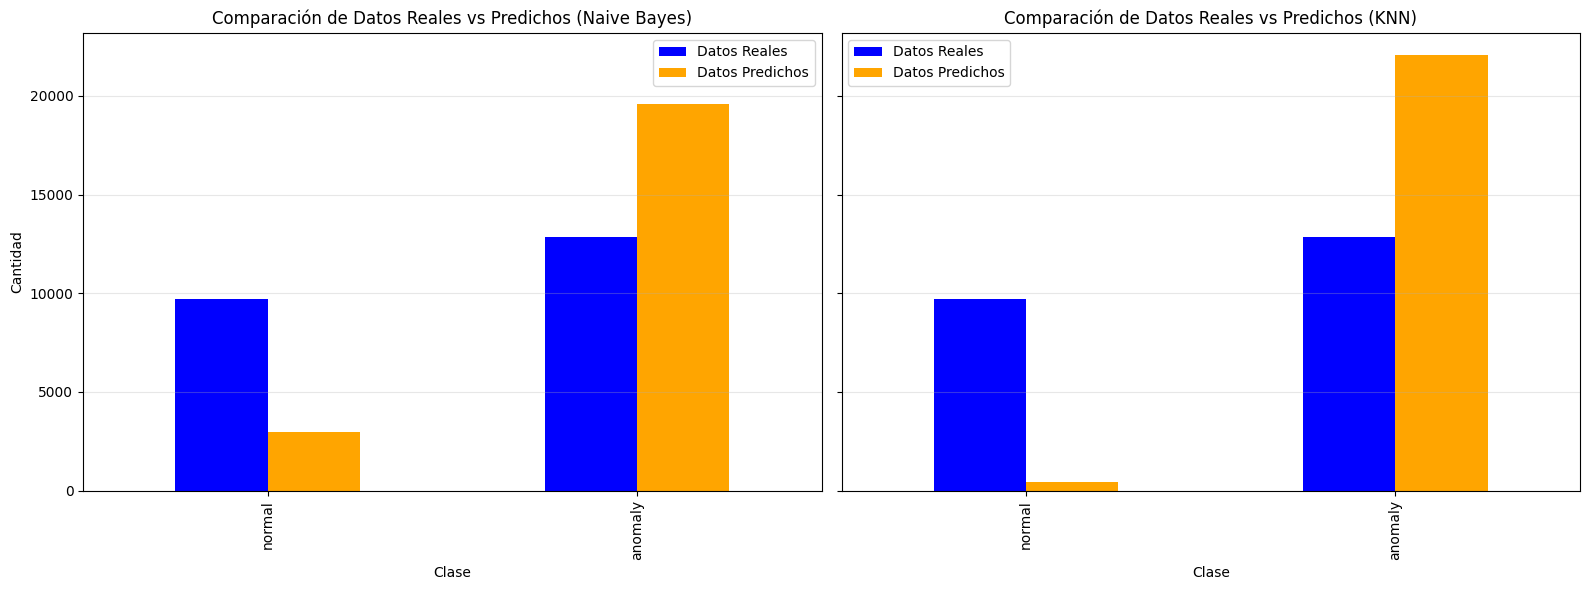

In [ ]:
def contar_datos(df, clase_real_col, prediccion_col):
    conteo_reales = df[clase_real_col].value_counts()
    conteo_predichos = df[prediccion_col].value_counts()
    normal_reales = conteo_reales.get('normal', 0)
    anomaly_reales = conteo_reales.get('anomaly', 0)

    normal_predichos = conteo_predichos.get('normal', 0)
    anomaly_predichos = conteo_predichos.get('anomaly', 0)
    resultados = pd.DataFrame({
        'Datos Reales': [normal_reales, anomaly_reales],
        'Datos Predichos': [normal_predichos, anomaly_predichos]
    }, index=['normal', 'anomaly'])

    return resultados

resultados_nb = contar_datos(df_prueba_Naive_Bayes, 'clase_real', 'prediccion')
resultados_knn = contar_datos(df_prueba_KNN, 'class', 'prediccion')
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
resultados_nb.plot(kind='bar', ax=axes[0], color=['blue', 'orange'])
axes[0].set_title('Comparación de Datos Reales vs Predichos (Naive Bayes)')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Cantidad')
axes[0].grid(axis='y', alpha=0.3)
resultados_knn.plot(kind='bar', ax=axes[1], color=['blue', 'orange'])
axes[1].set_title('Comparación de Datos Reales vs Predichos (KNN)')
axes[1].set_xlabel('Clase')
axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

en la grafica se puede evidenciar una comparacion de los obtenidos vs los datos reales, se puede observar que los modelos tienen poca precisión al identificar, esto puede suceder porque las variables escogidas no son las ideales para el analisis, se podria obtener una mejor predicción de los datos.